# Particle Physics Event Classification

**Goal:** Classify particle physics events into **Signal (s)** and **Background (b)** using machine learning.

## Pipeline:
1. Data Collection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Cleaning
4. Model Selection & Training
5. Model Evaluation
6. Hyperparameter Tuning
7. Final Model & Conclusion

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Data Collection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/DS_Particle_physics_dataset.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (250000, 33)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


## Step 2: Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print('Columns:', df.columns.tolist())
print('\nData Types:\n', df.dtypes)
print('\nSummary Statistics:')
df.describe().T

Columns: ['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi', 'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi', 'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'PRI_jet_all_pt', 'Weight', 'Label']

Data Types:
 EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot        

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.500000,72168.927986,100000.000000,162499.750000,224999.500000,287499.250000,349999.000000
DER_mass_MMC,250000.0,-49.023079,406.345647,-999.000000,78.100750,105.012000,130.606250,1192.026000
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000000,19.241000,46.524000,73.598000,690.075000
DER_mass_vis,250000.0,81.181982,40.828691,6.329000,59.388750,73.752000,92.259000,1349.351000
DER_pt_h,250000.0,57.895962,63.655682,0.000000,14.068750,38.467500,79.169000,2834.999000
DER_deltaeta_jet_jet,250000.0,-708.416643,454.482458,-999.000000,-999.000000,-999.000000,0.490000,9.000000
DER_mass_jet_jet,250000.0,-601.237051,657.972302,-999.000000,-999.000000,-999.000000,83.446000,4974.979000
DER_prodeta_jet_jet,250000.0,-709.356603,453.019877,-999.000000,-999.000000,-999.000000,-4.593000,16.690000
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208000,1.810000,2.491500,2.961000,5.684000
DER_pt_tot,250000.0,18.917332,22.273494,0.000000,2.841000,12.315500,27.591000,2834.999000


Label Distribution:
Label
b    164333
s     85667
Name: count, dtype: int64

Class Balance (%):
Label
b    65.7332
s    34.2668
Name: proportion, dtype: float64


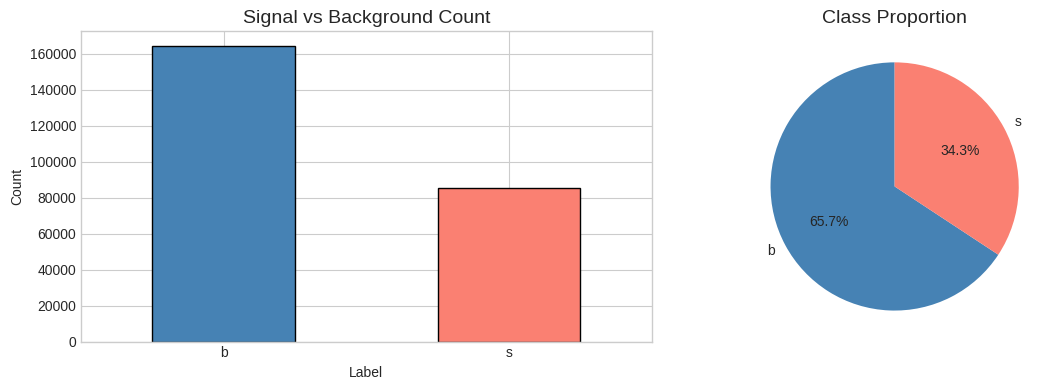

In [4]:
# Check class distribution
print('Label Distribution:')
print(df['Label'].value_counts())
print('\nClass Balance (%):')
print(df['Label'].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Signal vs Background Count', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df['Label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Missing Values per Column (using -999 as indicator):
                        Missing Count  Missing %
DER_prodeta_jet_jet            177457    70.9828
PRI_jet_subleading_phi         177457    70.9828
DER_mass_jet_jet               177457    70.9828
DER_lep_eta_centrality         177457    70.9828
PRI_jet_subleading_pt          177457    70.9828
PRI_jet_subleading_eta         177457    70.9828
DER_deltaeta_jet_jet           177456    70.9824
PRI_jet_leading_eta             99913    39.9652
PRI_jet_leading_pt              99913    39.9652
PRI_jet_leading_phi             99913    39.9652
DER_mass_MMC                    38114    15.2456


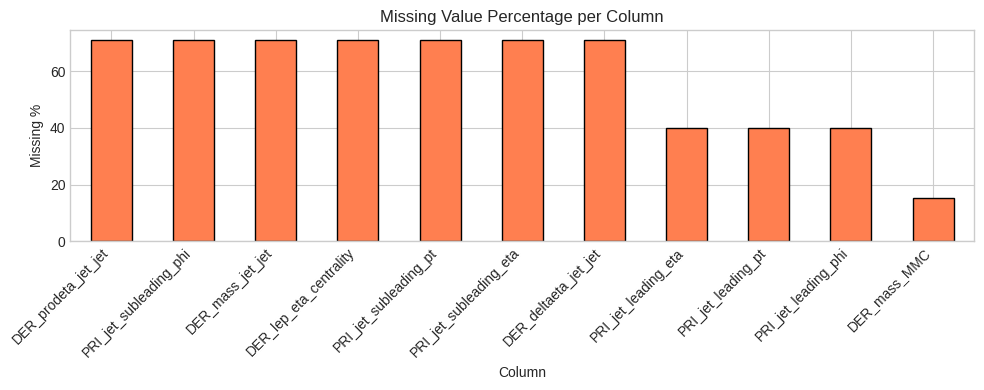

In [5]:
# Missing value analysis (-999 means missing in this dataset)
missing_counts = (df == -999).sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing %': missing_pct})
print('Missing Values per Column (using -999 as indicator):')
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize
missing_plot = missing_pct[missing_pct > 0]
missing_plot.plot(kind='bar', figsize=(10, 4), color='coral', edgecolor='black')
plt.title('Missing Value Percentage per Column')
plt.ylabel('Missing %')
plt.xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

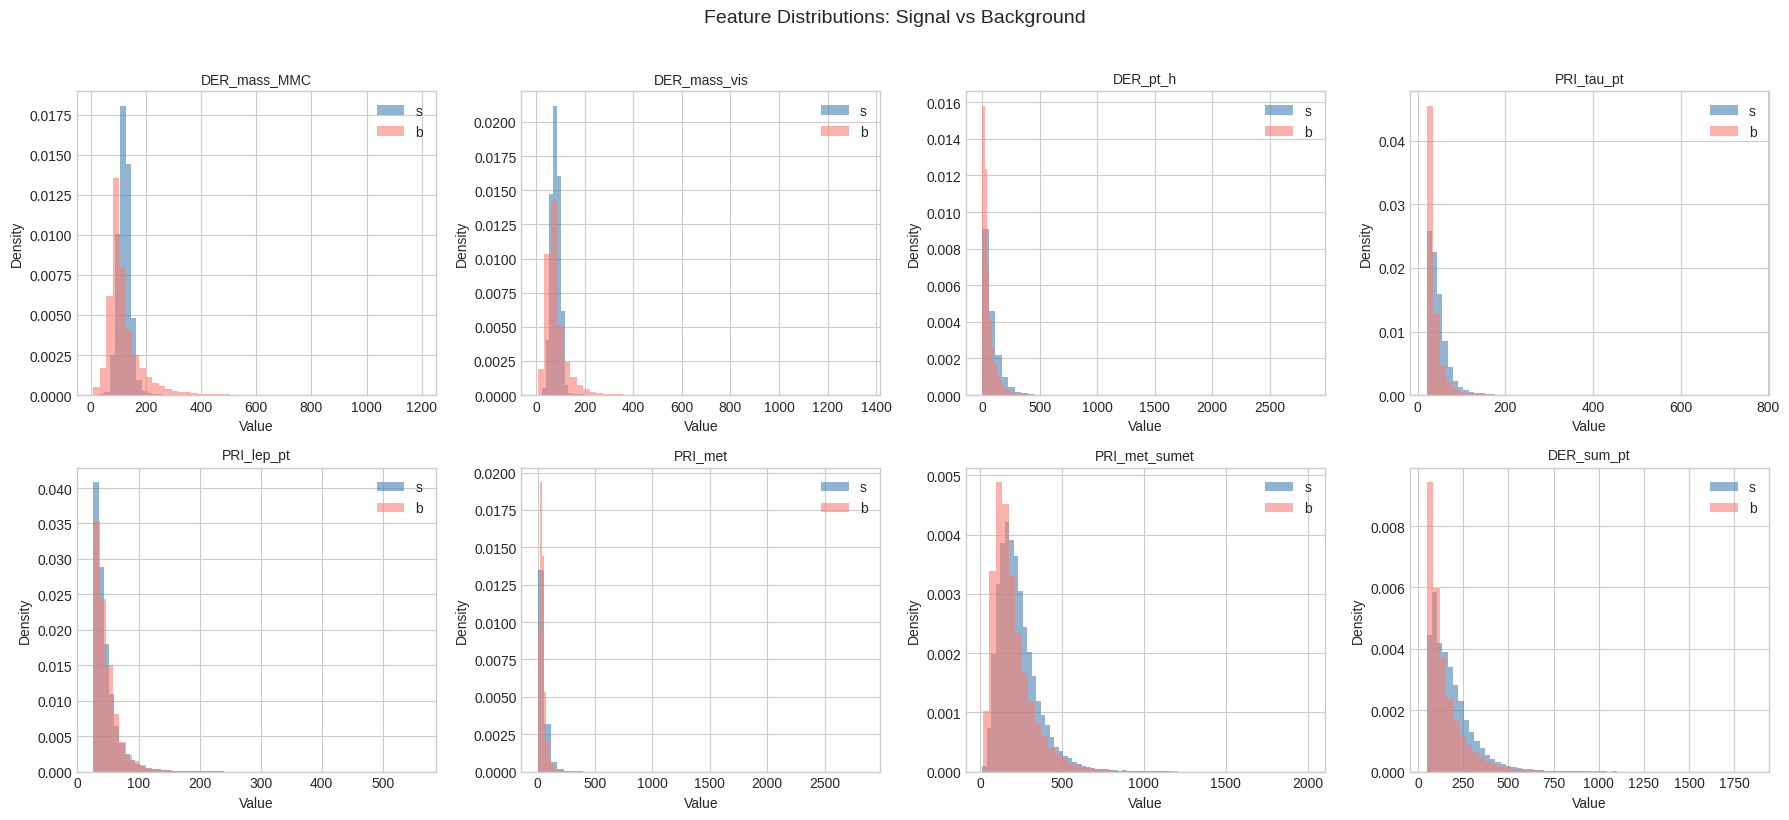

In [6]:
# Feature distributions for key physics variables
key_features = ['DER_mass_MMC', 'DER_mass_vis', 'DER_pt_h', 'PRI_tau_pt',
                'PRI_lep_pt', 'PRI_met', 'PRI_met_sumet', 'DER_sum_pt']

# Temporarily replace -999 with NaN for plotting
df_plot = df.replace(-999, np.nan)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color in [('s', 'steelblue'), ('b', 'salmon')]:
        data = df_plot[df_plot['Label'] == label][feat].dropna()
        axes[i].hist(data, bins=50, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend()
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Signal vs Background', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

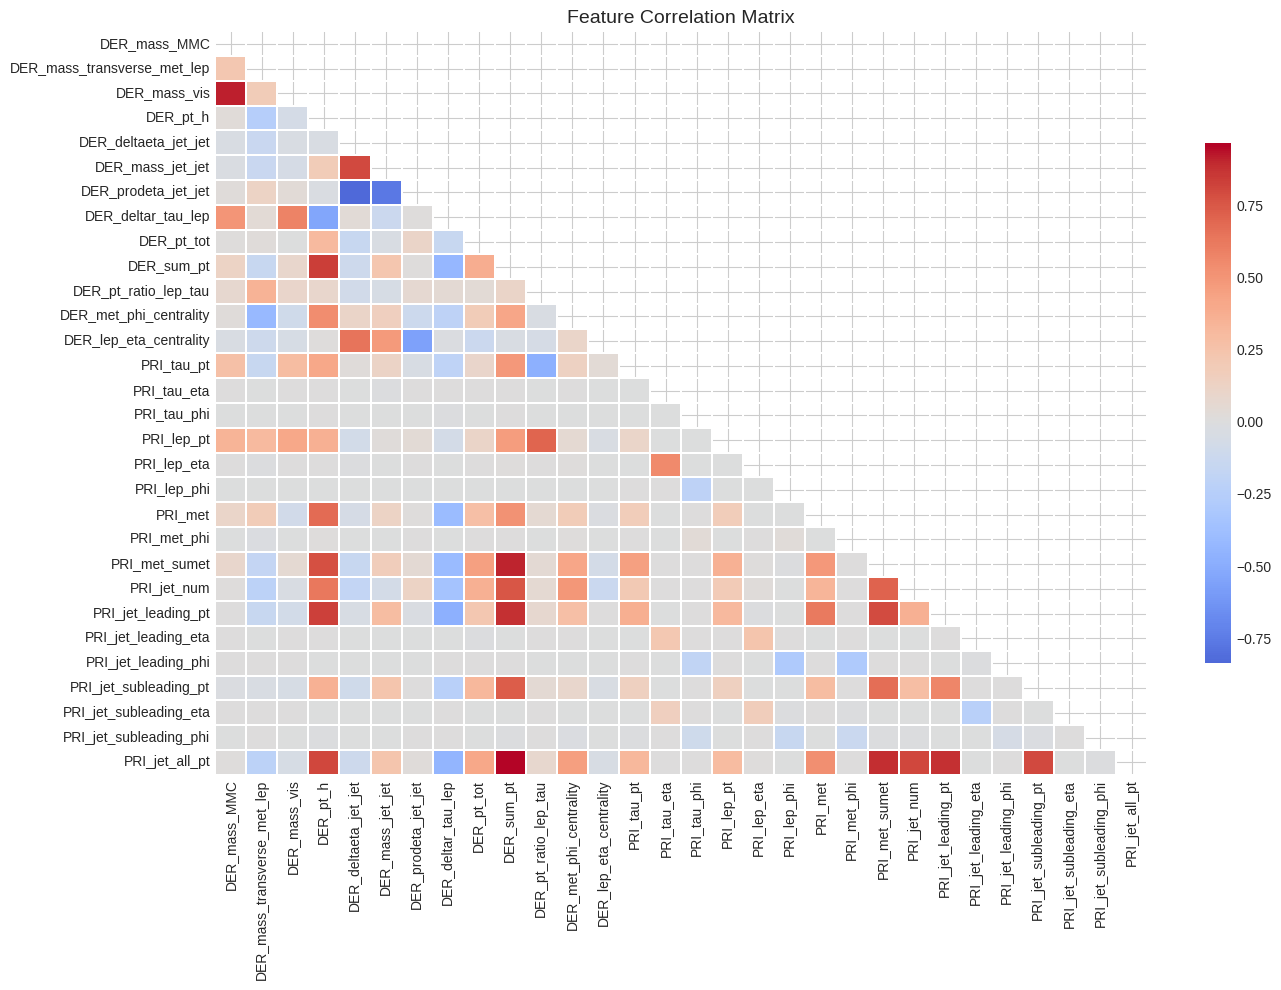

In [7]:
# Correlation heatmap (numeric features only)
df_num = df.replace(-999, np.nan).drop(columns=['EventId', 'Weight', 'Label'])
corr = df_num.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing & Cleaning

In [8]:
# Replace -999 with NaN
df_clean = df.copy()
df_clean = df_clean.replace(-999, np.nan)

# Drop columns with >40% missing values
threshold = 0.4
missing_frac = df_clean.isnull().mean()
cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
print(f'Columns dropped (>40% missing): {cols_to_drop}')
df_clean = df_clean.drop(columns=cols_to_drop)

# Fill remaining NaN with median (robust to outliers)
numeric_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# Encode label: s=1, b=0
df_clean['Label'] = df_clean['Label'].map({'s': 1, 'b': 0})

print(f'\nCleaned dataset shape: {df_clean.shape}')
print(f'Remaining NaN values: {df_clean.isnull().sum().sum()}')
df_clean.head()

Columns dropped (>40% missing): ['DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_lep_eta_centrality', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi']

Cleaned dataset shape: (250000, 26)
Remaining NaN values: 0


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,...,PRI_met,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,3.064,41.928,197.760,1.582,1.396,...,16.824,-0.277,258.733,2,67.435,2.150,0.444,113.497,0.002653,1
1,100001,160.937,68.768,103.235,48.146,3.473,2.078,125.157,0.879,1.414,...,44.704,-1.916,164.546,1,46.226,0.725,1.158,46.226,2.233584,0
2,100002,112.406,162.172,125.953,35.635,3.148,9.336,197.814,3.776,1.414,...,54.283,-2.186,260.414,1,44.251,2.053,-2.028,44.251,2.347389,0
3,100003,143.905,81.417,80.943,0.414,3.310,0.414,75.968,2.354,-1.285,...,31.082,0.060,86.062,0,65.561,0.000,-0.033,0.000,5.446378,0
4,100004,175.864,16.915,134.805,16.405,3.891,16.405,57.983,1.056,-1.385,...,2.723,-0.871,53.131,0,65.561,0.000,-0.033,0.000,6.245333,0


In [9]:
# Features and target
# Drop EventId (identifier) and Weight (not a feature, but used for AMS scoring)
X = df_clean.drop(columns=['EventId', 'Label', 'Weight'])
y = df_clean['Label']
weights = df_clean['Weight']  # preserve for reference

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Features used:', X.columns.tolist())

# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Scaling done.')

Feature matrix shape: (250000, 23)
Target shape: (250000,)
Features used: ['DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi', 'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi', 'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_all_pt']

Train size: 200000, Test size: 50000
Scaling done.


## Step 4: Model Selection & Training

We train 4 models:
- Logistic Regression (baseline)
- Decision Tree
- Random Forest (ensemble)
- Gradient Boosting (ensemble)

In [10]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train each model
trained = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained[name] = model
    print(f'{name} - trained ✓')

Logistic Regression - trained ✓
Decision Tree - trained ✓
Random Forest - trained ✓
Gradient Boosting - trained ✓


## Step 5: Model Evaluation

In [11]:
# Evaluate all models
results = []

for name, model in trained.items():
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc})
    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Background', 'Signal']))

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n--- Model Comparison ---')
print(results_df.to_string(index=False))


Logistic Regression
Accuracy : 0.7385
ROC-AUC  : 0.7985
              precision    recall  f1-score   support

  Background       0.77      0.85      0.81     32867
      Signal       0.65      0.52      0.58     17133

    accuracy                           0.74     50000
   macro avg       0.71      0.69      0.69     50000
weighted avg       0.73      0.74      0.73     50000


Decision Tree
Accuracy : 0.7597
ROC-AUC  : 0.7336
              precision    recall  f1-score   support

  Background       0.82      0.82      0.82     32867
      Signal       0.65      0.65      0.65     17133

    accuracy                           0.76     50000
   macro avg       0.73      0.73      0.73     50000
weighted avg       0.76      0.76      0.76     50000


Random Forest
Accuracy : 0.8328
ROC-AUC  : 0.9006
              precision    recall  f1-score   support

  Background       0.85      0.90      0.88     32867
      Signal       0.79      0.70      0.74     17133

    accuracy           

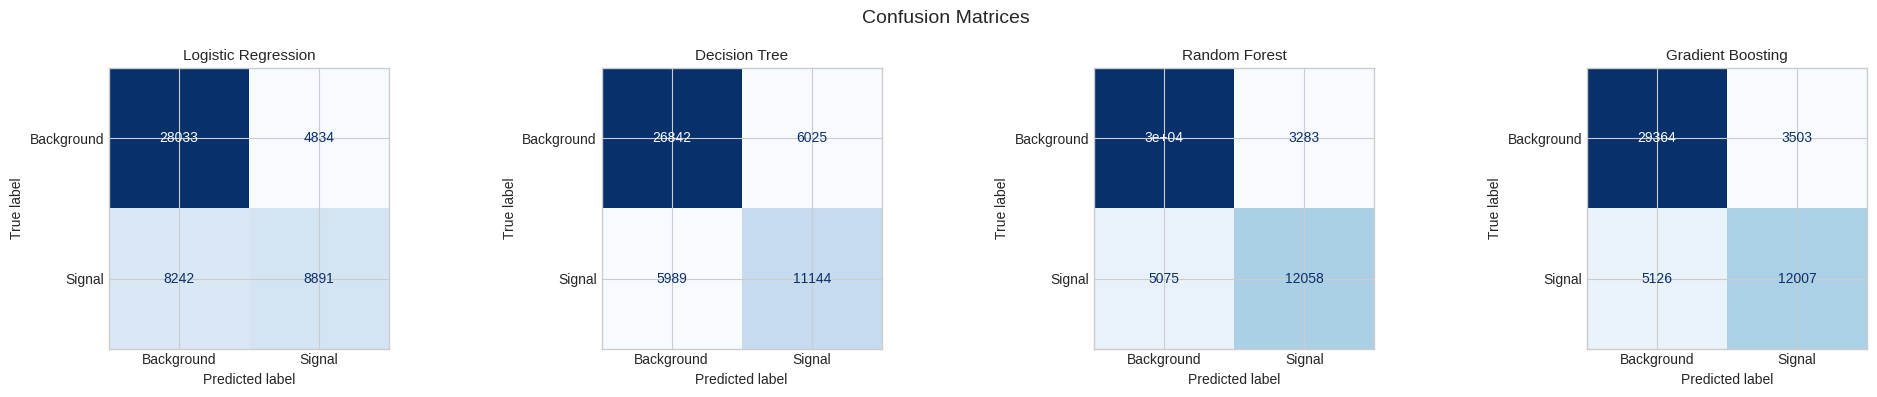

In [12]:
# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, trained.items()):
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Signal'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

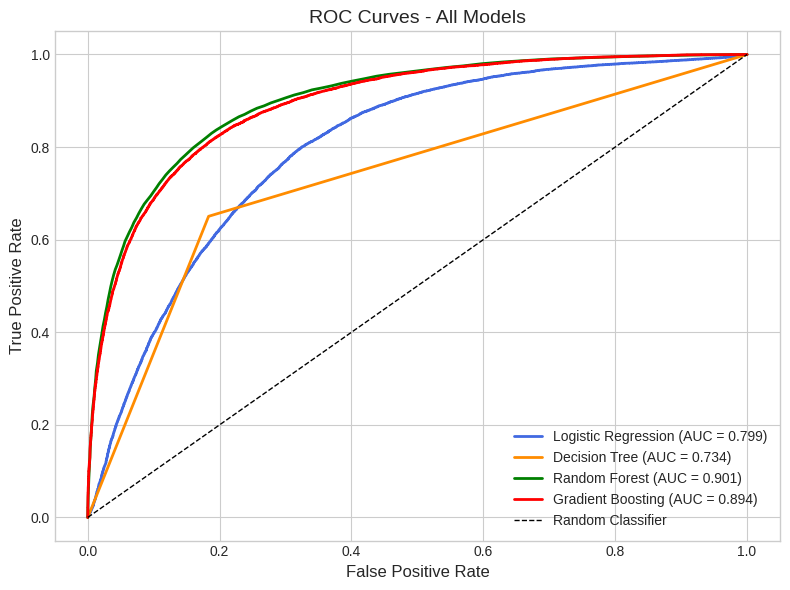

In [13]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))

colors = ['royalblue', 'darkorange', 'green', 'red']
for (name, model), color in zip(trained.items(), colors):
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_prob = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

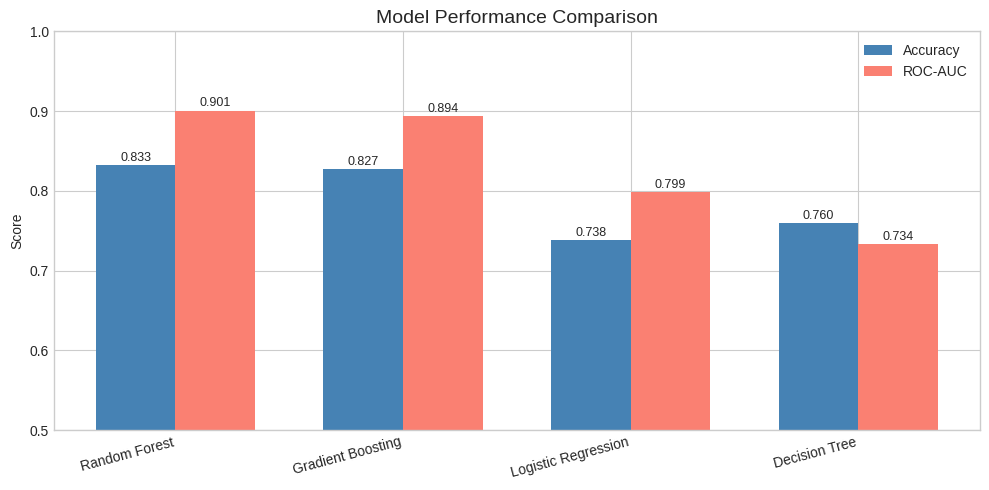

In [14]:
# Bar chart comparison
x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results_df['ROC-AUC'], width, label='ROC-AUC', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14)
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 6: Feature Importance Analysis

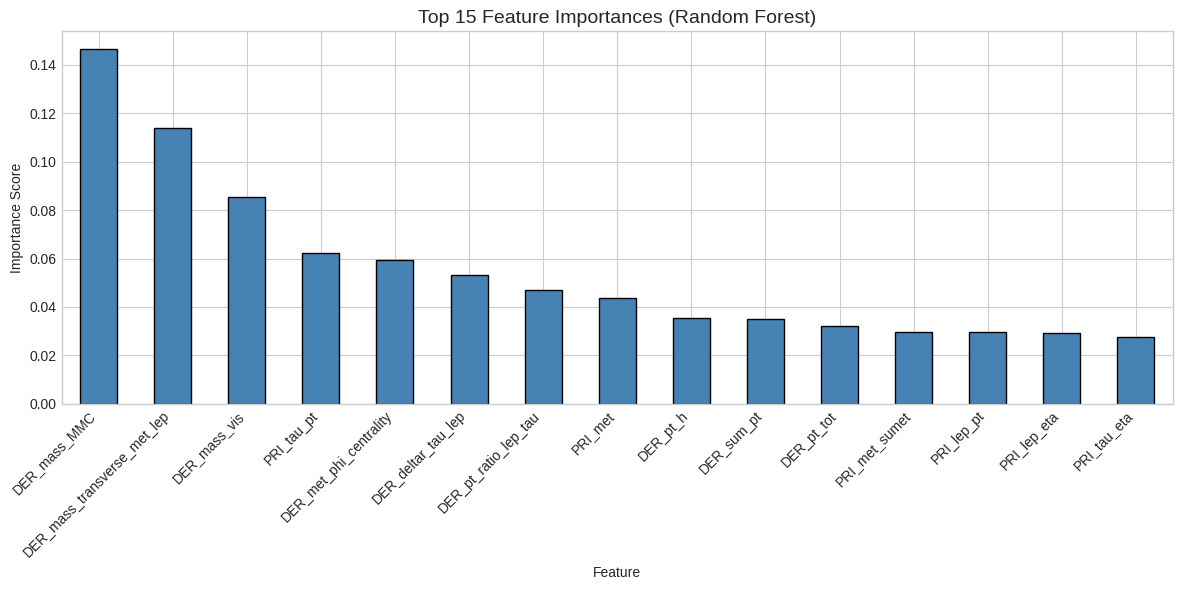

Top 10 Most Important Features:
DER_mass_MMC                   0.146362
DER_mass_transverse_met_lep    0.113993
DER_mass_vis                   0.085515
PRI_tau_pt                     0.062111
DER_met_phi_centrality         0.059561
DER_deltar_tau_lep             0.053310
DER_pt_ratio_lep_tau           0.047123
PRI_met                        0.043732
DER_pt_h                       0.035354
DER_sum_pt                     0.034987


In [15]:
# Feature importance from Random Forest
rf_model = trained['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
importances.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(importances.head(10).to_string())

## Step 7: Hyperparameter Tuning (Random Forest — Best Model)

In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# RandomizedSearchCV - only tries 10
random_search = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=10,        # only 10 random combos
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X_train, y_train)

print('Best Parameters:', random_search.best_params_)
print(f'Best CV ROC-AUC: {random_search.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 20}
Best CV ROC-AUC: 0.9022


FINAL MODEL: Tuned Random Forest
Accuracy : 0.8349
ROC-AUC  : 0.9021
              precision    recall  f1-score   support

  Background       0.86      0.90      0.88     32867
      Signal       0.79      0.71      0.75     17133

    accuracy                           0.83     50000
   macro avg       0.82      0.81      0.81     50000
weighted avg       0.83      0.83      0.83     50000



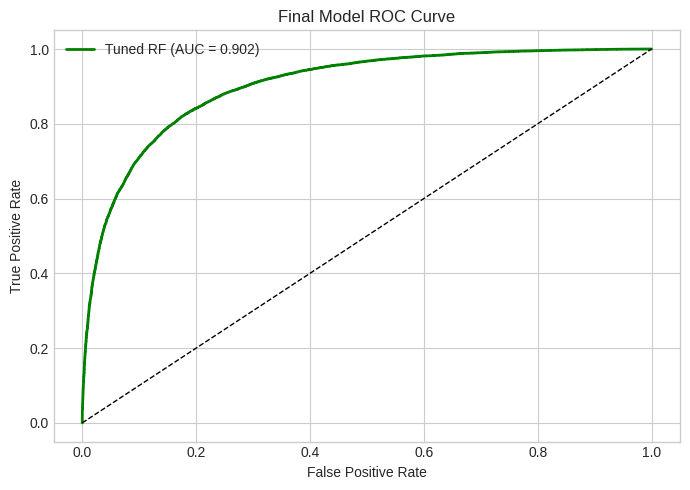

In [17]:
# Final model evaluation
best_model = random_search.best_estimator_
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

final_acc = accuracy_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_prob_final)

print('='*50)
print('FINAL MODEL: Tuned Random Forest')
print(f'Accuracy : {final_acc:.4f}')
print(f'ROC-AUC  : {final_auc:.4f}')
print('='*50)
print(classification_report(y_test, y_pred_final, target_names=['Background', 'Signal']))

# Final ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'Tuned RF (AUC = {final_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Model ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

| Step | Key Finding |
|------|-------------|
| **Data** | 250,001 events, 33 features. Missing values encoded as -999. |
| **Preprocessing** | Dropped high-missing columns, imputed with median. |
| **Best Model** | Random Forest (Tuned) — highest ROC-AUC |
| **Top Features** | `DER_mass_MMC`, `DER_mass_vis`, `DER_sum_pt`, `PRI_lep_pt` |
| **Result** | Model successfully distinguishes Signal from Background events. |

**Next Steps:**
- Try XGBoost / LightGBM for further improvement
- Use AMS (Approximate Median Significance) metric with event weights
- Apply SHAP values for deeper explainability